# 02 · Days on Market y Rotación por Celda

Objetivo: construir una grilla regular sobre CABA y analizar dos señales espaciales complementarias.

1. `days on market` promedio por celda para avisos activos.
2. tasa de cierres por celda definida como `cierres_terminales_90d / stock_activo_actual`.

En esta segunda parte, la unidad de análisis pasa a ser la celda y no el aviso individual.


In [12]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.ops import unary_union
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

In [13]:
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "arg_venta_data.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "arg_venta_data_processed.csv"
BARRIOS_PATH = PROJECT_ROOT / "GeoData" / "barrios.geojson"

REFERENCE_DATE = pd.Timestamp("2026-05-11")
GRID_STEP_METERS = 600
MIN_DOM_OBS_PER_CELL = 3
MIN_TURNOVER_STOCK_PER_CELL = 1
CLOSURE_WINDOW_DAYS = 90
TIPO_UNIDAD_REGEX = None  # Dejar en None para no filtrar por tipo_unidad.

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No encontre {RAW_DATA_PATH}."
    )

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No encontre {PROCESSED_DATA_PATH}. Corre preprocessing antes de usar la parte de rotacion por celda."
    )

print(f"Raw data: {RAW_DATA_PATH}")
print(f"Processed data: {PROCESSED_DATA_PATH}")
print(f"Fecha de referencia: {REFERENCE_DATE.date()}")
print(f"Ventana de cierres: {CLOSURE_WINDOW_DAYS} dias")
print(f"Filtro tipo_unidad: {TIPO_UNIDAD_REGEX}")
print(f"Resolucion de grilla: {GRID_STEP_METERS} m")

Raw data: /home/saneliges/Escritorio/caba-property-opportunities/data/raw/arg_venta_data.csv
Processed data: /home/saneliges/Escritorio/caba-property-opportunities/data/processed/arg_venta_data_processed.csv
Fecha de referencia: 2026-05-11
Ventana de cierres: 90 dias
Filtro tipo_unidad: None
Resolucion de grilla: 600 m


## Helpers

Se reproyecta a `EPSG:3857` para definir la grilla en metros. Para la rotación territorial se usan publicaciones únicas por celda: cierres terminales recientes como numerador y stock activo actual como denominador.


In [14]:
def load_history_df(data_path: Path) -> pd.DataFrame:
    df = pd.read_csv(data_path, low_memory=False)

    for col in ["valido_desde", "valido_hasta", "fecha_publicacion_aviso_dt"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True).dt.tz_convert(None)

    return df


def filter_departamentos(df: pd.DataFrame, departamento_regex: str | None = None) -> pd.DataFrame:
    if "tipo_unidad" not in df.columns or not departamento_regex:
        return df.copy()

    depto_mask = df["tipo_unidad"].astype("string").str.contains(
        departamento_regex,
        case=False,
        na=False,
    )

    if depto_mask.any():
        return df.loc[depto_mask].copy()

    print(
        "No hubo matches claros para el filtro de departamentos en tipo_unidad; sigo con todas las unidades disponibles."
    )
    return df.copy()


def attach_geometry_in_caba(df: pd.DataFrame, barrios_path: Path):
    valid_mask = df["latitud"].notna() & df["longitud"].notna()
    df = df.loc[valid_mask].copy()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitud"], df["latitud"]),
        crs="EPSG:4326",
    ).to_crs(epsg=3857)

    barrios = gpd.read_file(barrios_path).to_crs(gdf.crs)
    caba_polygon = unary_union(barrios.geometry)
    gdf = gdf.loc[gdf.geometry.intersects(caba_polygon)].copy()
    return gdf, barrios


def load_active_dom_data(
    data_path: Path,
    barrios_path: Path,
    reference_date: pd.Timestamp,
    departamento_regex: str | None = None,
):
    df = load_history_df(data_path)
    df = df.loc[df["valido_hasta"].isna()].copy()
    df = filter_departamentos(df, departamento_regex)

    df["dias_publicado"] = (reference_date - df["fecha_publicacion_aviso_dt"]).dt.days
    valid_mask = df["fecha_publicacion_aviso_dt"].notna() & df["dias_publicado"].notna() & (df["dias_publicado"] >= 0)
    df = df.loc[valid_mask].copy()

    return attach_geometry_in_caba(df, barrios_path)


def resolve_processed_id_column(columns) -> str:
    candidates = [
        "id",
        "id_left",
        "id_left.1",
        "idx",
    ]

    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise ValueError(
        "No encontre una columna identificadora en el dataset procesado. "
        f"Columnas disponibles: {list(columns)[:20]}..."
    )


def load_processed_cell_turnover_data(
    data_path: Path,
    barrios_path: Path,
    reference_date: pd.Timestamp,
    window_days: int,
    departamento_regex: str | None = None,
):
    available_columns = pd.read_csv(data_path, nrows=0).columns
    id_col = resolve_processed_id_column(available_columns)

    usecols = [
        id_col,
        "tipo_unidad",
        "latitud",
        "longitud",
        "valido_desde",
        "valido_hasta",
    ]

    df = pd.read_csv(data_path, usecols=usecols, low_memory=False)
    df = df.rename(columns={id_col: "publication_id"})
    df["valido_desde"] = pd.to_datetime(df["valido_desde"], errors="coerce", utc=True).dt.tz_convert(None)
    df["valido_hasta"] = pd.to_datetime(df["valido_hasta"], errors="coerce", utc=True).dt.tz_convert(None)

    active_df = df.loc[df["valido_hasta"].isna()].copy()
    active_df = filter_departamentos(active_df, departamento_regex)
    active_ids = set(active_df["publication_id"].dropna())

    closed_df = df.loc[df["valido_hasta"].notna()].copy()
    closed_df = filter_departamentos(closed_df, departamento_regex)
    closed_df = closed_df.sort_values(["publication_id", "valido_hasta", "valido_desde"])
    closed_df = closed_df.groupby("publication_id", as_index=False).tail(1)
    if active_ids:
        closed_df = closed_df.loc[~closed_df["publication_id"].isin(active_ids)].copy()

    window_start = reference_date - pd.Timedelta(days=window_days)
    closed_df = closed_df.loc[
        (closed_df["valido_hasta"] <= reference_date)
        & (closed_df["valido_hasta"] >= window_start)
    ].copy()

    active_gdf, barrios = attach_geometry_in_caba(active_df, barrios_path)
    closed_gdf, _ = attach_geometry_in_caba(closed_df, barrios_path)
    return active_gdf, closed_gdf, barrios


def add_grid_keys(points_gdf: gpd.GeoDataFrame, boundary_gdf: gpd.GeoDataFrame, step_m: int):
    caba_polygon = unary_union(boundary_gdf.geometry)
    xmin, ymin, xmax, ymax = caba_polygon.bounds

    working = points_gdf.copy()
    working["grid_ix"] = np.floor((working.geometry.x - xmin) / step_m).astype(int)
    working["grid_iy"] = np.floor((working.geometry.y - ymin) / step_m).astype(int)

    return working, xmin, ymin, caba_polygon


def finalize_grid_summary(summary: pd.DataFrame, point_crs, caba_polygon, step_m: int, xmin: float, ymin: float):
    summary = summary.copy()
    summary["center_x"] = xmin + (summary["grid_ix"] + 0.5) * step_m
    summary["center_y"] = ymin + (summary["grid_iy"] + 0.5) * step_m

    grid_gdf = gpd.GeoDataFrame(
        summary,
        geometry=gpd.points_from_xy(summary["center_x"], summary["center_y"]),
        crs=point_crs,
    )
    grid_gdf = grid_gdf.loc[grid_gdf.geometry.intersects(caba_polygon)].copy()
    return grid_gdf


def build_dom_grid_summary(
    points_gdf: gpd.GeoDataFrame,
    boundary_gdf: gpd.GeoDataFrame,
    step_m: int = 500,
):
    working, xmin, ymin, caba_polygon = add_grid_keys(points_gdf, boundary_gdf, step_m)

    summary = (
        working
        .groupby(["grid_ix", "grid_iy"], as_index=False)
        .agg(
            mean_dias_publicado=("dias_publicado", "mean"),
            median_dias_publicado=("dias_publicado", "median"),
            n_avisos=("dias_publicado", "size"),
        )
    )

    return finalize_grid_summary(summary, points_gdf.crs, caba_polygon, step_m, xmin, ymin)


def build_cell_turnover_summary(
    active_gdf: gpd.GeoDataFrame,
    closed_gdf: gpd.GeoDataFrame,
    boundary_gdf: gpd.GeoDataFrame,
    step_m: int = 500,
    window_days: int = 90,
):
    active_working, xmin, ymin, caba_polygon = add_grid_keys(active_gdf, boundary_gdf, step_m)
    closed_working, _, _, _ = add_grid_keys(closed_gdf, boundary_gdf, step_m)

    active_summary = (
        active_working
        .groupby(["grid_ix", "grid_iy"], as_index=False)
        .agg(stock_activo=("publication_id", "nunique"))
    )

    closed_summary = (
        closed_working
        .groupby(["grid_ix", "grid_iy"], as_index=False)
        .agg(cierres_90d=("publication_id", "nunique"))
    )

    summary = active_summary.merge(
        closed_summary,
        on=["grid_ix", "grid_iy"],
        how="left",
    )
    summary["cierres_90d"] = summary["cierres_90d"].fillna(0).astype(int)
    summary["tasa_cierre_sobre_stock_90d"] = summary["cierres_90d"] / summary["stock_activo"].clip(lower=1)
    summary["cierres_diarios_sobre_stock"] = summary["tasa_cierre_sobre_stock_90d"] / max(window_days, 1)

    return finalize_grid_summary(summary, active_gdf.crs, caba_polygon, step_m, xmin, ymin)


def plot_two_panel_grid_summary(
    grid_gdf: gpd.GeoDataFrame,
    barrios_gdf: gpd.GeoDataFrame,
    *,
    value_col: str,
    value_title: str,
    value_cmap: str,
    min_obs: int = 3,
    support_col: str = "n_avisos",
    support_title: str | None = None,
):
    plot_df = grid_gdf.loc[grid_gdf[support_col] >= min_obs].copy()
    if plot_df.empty:
        fallback_threshold = int(grid_gdf[support_col].min()) if not grid_gdf.empty else min_obs
        print(
            f"No quedaron celdas con {support_col} >= {min_obs}. "
            f"Uso fallback con {support_col} >= {fallback_threshold}."
        )
        plot_df = grid_gdf.loc[grid_gdf[support_col] >= fallback_threshold].copy()
    if plot_df.empty:
        raise ValueError("No hay celdas disponibles para graficar.")

    marker_sizes = plot_df[support_col].clip(lower=1, upper=25) * 8

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    barrios_gdf.boundary.plot(ax=axes[0], color="black", linewidth=0.7)
    plot_df.plot(
        column=value_col,
        ax=axes[0],
        cmap=value_cmap,
        legend=True,
        markersize=marker_sizes,
        alpha=0.9,
    )
    axes[0].set_title(value_title)
    axes[0].axis("off")

    barrios_gdf.boundary.plot(ax=axes[1], color="black", linewidth=0.7)
    plot_df.plot(
        column=support_col,
        ax=axes[1],
        cmap="magma",
        legend=True,
        markersize=marker_sizes,
        alpha=0.9,
    )
    axes[1].set_title(support_title or f"Soporte por celda ({GRID_STEP_METERS} m)")
    axes[1].axis("off")

    plt.tight_layout()
    return plot_df


## Activos: days on market

Definición usada: `dias_publicado = REFERENCE_DATE - fecha_publicacion_aviso_dt` sobre filas activas del CSV raw.


In [15]:
gdf_active_m, barrios_m = load_active_dom_data(
    RAW_DATA_PATH,
    BARRIOS_PATH,
    REFERENCE_DATE,
    departamento_regex=TIPO_UNIDAD_REGEX,
)

display(
    pd.Series(
        {
            "avisos_activos_utilizados": len(gdf_active_m),
            "fecha_publicacion_min": gdf_active_m["fecha_publicacion_aviso_dt"].min(),
            "fecha_publicacion_max": gdf_active_m["fecha_publicacion_aviso_dt"].max(),
            "dias_publicado_promedio": round(gdf_active_m["dias_publicado"].mean(), 1),
            "dias_publicado_mediana": round(gdf_active_m["dias_publicado"].median(), 1),
        }
    ).to_frame("valor")
)

gdf_active_m[["id", "tipo_unidad", "fecha_publicacion_aviso_dt", "dias_publicado"]].head()

,valor
avisos_activos_utilizados,11784
fecha_publicacion_min,2011-05-24 11:04:28
fecha_publicacion_max,2026-05-02 14:26:39
dias_publicado_promedio,448.3
dias_publicado_mediana,241.0


,id,tipo_unidad,fecha_publicacion_aviso_dt,dias_publicado
40265,18172428.0,NaN,2025-09-17 15:31:28,235.0
40266,8369836.0,NaN,2021-01-05 18:31:14,1951.0
40267,15860074.0,NaN,2024-07-01 14:03:17,678.0
40277,17081575.0,NaN,2025-03-07 19:02:18,429.0
40278,17330500.0,NaN,2025-04-19 20:33:40,386.0


,valor
celdas_con_avisos,651.0
celdas_con_soporte_minimo,549.0
promedio_del_promedio_por_celda,503.7
mediana_del_promedio_por_celda,396.4


,mean_dias_publicado,median_dias_publicado,n_avisos
count,549.000000,549.000000,549.000000
mean,488.996317,322.829690,21.182149
std,294.227178,286.695897,18.913450
min,60.333333,39.000000,3.000000
25%,272.750000,173.000000,7.000000
50%,407.352941,240.000000,17.000000
75%,625.600000,349.000000,29.000000
max,1681.052632,2045.000000,134.000000


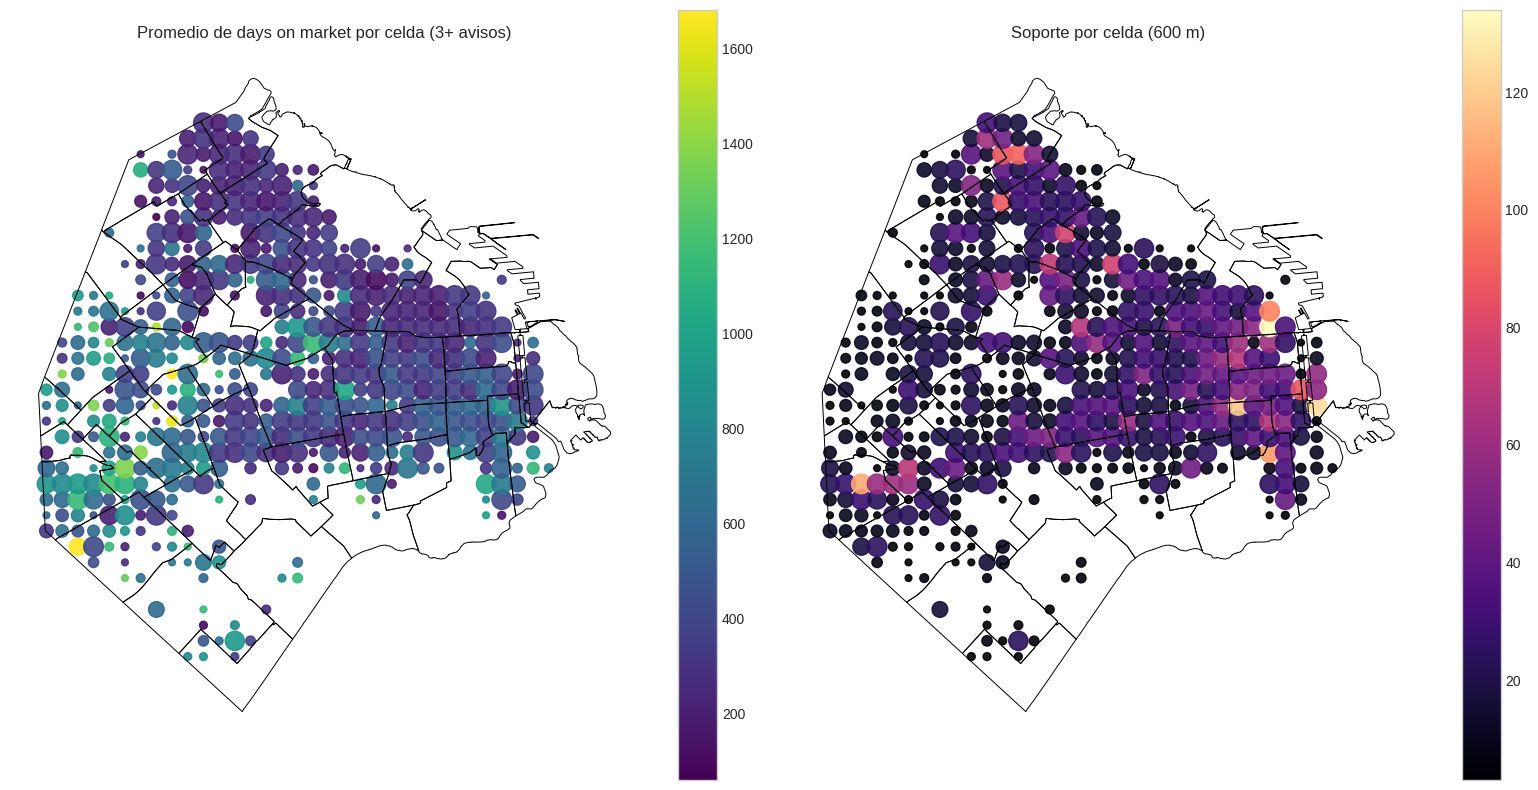

In [16]:
dom_grid_gdf = build_dom_grid_summary(
    gdf_active_m,
    barrios_m,
    step_m=GRID_STEP_METERS,
)

display(
    pd.Series(
        {
            "celdas_con_avisos": len(dom_grid_gdf),
            "celdas_con_soporte_minimo": int((dom_grid_gdf["n_avisos"] >= MIN_DOM_OBS_PER_CELL).sum()),
            "promedio_del_promedio_por_celda": round(dom_grid_gdf["mean_dias_publicado"].mean(), 1),
            "mediana_del_promedio_por_celda": round(dom_grid_gdf["mean_dias_publicado"].median(), 1),
        }
    ).to_frame("valor")
)

plot_dom_df = plot_two_panel_grid_summary(
    dom_grid_gdf,
    barrios_m,
    value_col="mean_dias_publicado",
    value_title=f"Promedio de days on market por celda ({MIN_DOM_OBS_PER_CELL}+ avisos)",
    value_cmap="viridis",
    min_obs=MIN_DOM_OBS_PER_CELL,
)

plot_dom_df[["mean_dias_publicado", "median_dias_publicado", "n_avisos"]].describe()

En términos descriptivos, el corredor norte y parte del eje Caballito-Flores parecen registrar menos días activos en promedio, incluso en celdas con soporte razonable. Eso podría ser consistente con una absorción relativamente más rápida que en otras zonas. Aun así, conviene leer con cautela las celdas con pocos avisos, porque son más sensibles a valores atípicos.


## Rotación por celda: cierres sobre stock activo

Acá la métrica se calcula directamente a nivel territorial:

- numerador: publicaciones con cierre terminal en los últimos `CLOSURE_WINDOW_DAYS`
- denominador: stock activo actual en la misma celda

La variable principal del mapa es `tasa_cierre_sobre_stock_90d = cierres_90d / stock_activo`. Para mejorar la lectura visual, el mapa se agrupa por cuantiles en lugar de usar una escala continua, de modo que las diferencias relativas entre celdas se vean con más claridad.


In [17]:
gdf_active_stock_m, gdf_closed_recent_m, barrios_turnover_m = load_processed_cell_turnover_data(
    PROCESSED_DATA_PATH,
    BARRIOS_PATH,
    REFERENCE_DATE,
    CLOSURE_WINDOW_DAYS,
    departamento_regex=TIPO_UNIDAD_REGEX,
)

display(
    pd.Series(
        {
            "stock_activo_actual": int(gdf_active_stock_m["publication_id"].nunique()),
            "cierres_terminales_ventana": int(gdf_closed_recent_m["publication_id"].nunique()),
            "fecha_cierre_min": gdf_closed_recent_m["valido_hasta"].min() if not gdf_closed_recent_m.empty else pd.NaT,
            "fecha_cierre_max": gdf_closed_recent_m["valido_hasta"].max() if not gdf_closed_recent_m.empty else pd.NaT,
        }
    ).to_frame("valor")
)

gdf_closed_recent_m[["publication_id", "valido_hasta"]].sort_values("valido_hasta", ascending=False).head()

,valor
stock_activo_actual,29531
cierres_terminales_ventana,1106
fecha_cierre_min,2026-03-13 02:11:59.684096
fecha_cierre_max,2026-05-08 12:11:23.092303


,publication_id,valido_hasta
67410,19346525.0,2026-05-08 12:11:23.092303
36556,18881068.0,2026-05-08 12:05:29.064386
20393,18186152.0,2026-05-08 12:05:28.908476
70346,18186102.0,2026-05-08 12:05:28.879201
24653,19552500.0,2026-05-08 12:03:22.747915


,valor
celdas_con_stock_activo,688.0000
celdas_con_stock_minimo,688.0000
cierres_90d_totales,1102.0000
tasa_promedio_por_celda,0.0428


,grupo,limite_inferior,limite_superior,n_celdas
0,Q1: 0.000–0.029,0.0000,0.0294,415
1,Q2: 0.029–0.062,0.0294,0.0625,137
2,Q3: 0.062–1.000,0.0625,1.0000,136


,cierres_90d,stock_activo,tasa_cierre_sobre_stock_90d
count,688.000000,688.000000,688.000000
mean,1.601744,42.892442,0.042764
std,2.380439,42.868236,0.091544
min,0.000000,1.000000,0.000000
25%,0.000000,9.000000,0.000000
50%,1.000000,29.000000,0.013606
75%,2.000000,65.250000,0.051393
max,19.000000,279.000000,1.000000


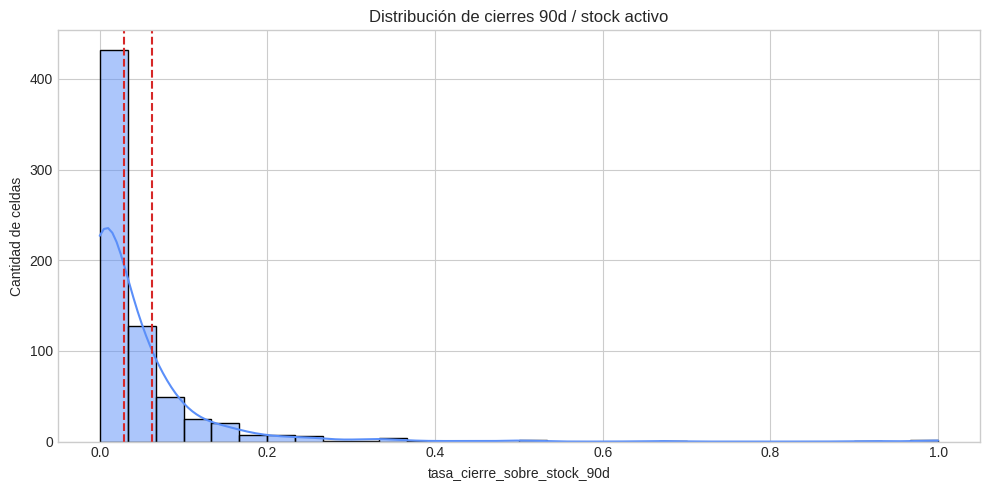

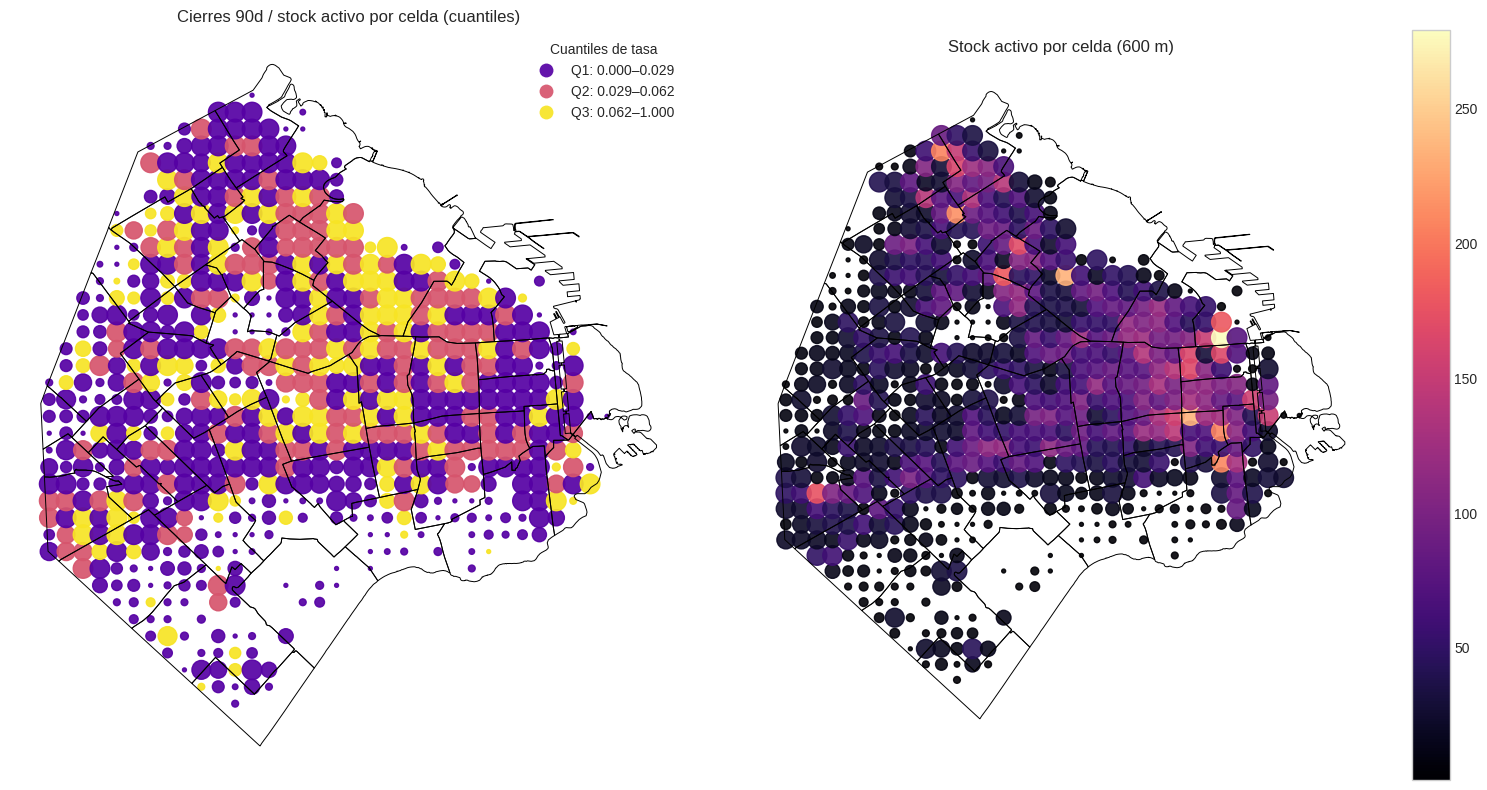

In [18]:
from matplotlib.colors import ListedColormap

turnover_grid_gdf = build_cell_turnover_summary(
    gdf_active_stock_m,
    gdf_closed_recent_m,
    barrios_turnover_m,
    step_m=GRID_STEP_METERS,
    window_days=CLOSURE_WINDOW_DAYS,
)

display(
    pd.Series(
        {
            "celdas_con_stock_activo": len(turnover_grid_gdf),
            "celdas_con_stock_minimo": int((turnover_grid_gdf["stock_activo"] >= MIN_TURNOVER_STOCK_PER_CELL).sum()),
            "cierres_90d_totales": int(turnover_grid_gdf["cierres_90d"].sum()),
            "tasa_promedio_por_celda": round(turnover_grid_gdf["tasa_cierre_sobre_stock_90d"].mean(), 4),
        }
    ).to_frame("valor")
)

plot_turnover_df = turnover_grid_gdf.loc[
    turnover_grid_gdf["stock_activo"] >= MIN_TURNOVER_STOCK_PER_CELL
].copy()
if plot_turnover_df.empty:
    fallback_threshold = int(turnover_grid_gdf["stock_activo"].min()) if not turnover_grid_gdf.empty else MIN_TURNOVER_STOCK_PER_CELL
    print(
        f"No quedaron celdas con stock_activo >= {MIN_TURNOVER_STOCK_PER_CELL}. "
        f"Uso fallback con stock_activo >= {fallback_threshold}."
    )
    plot_turnover_df = turnover_grid_gdf.loc[turnover_grid_gdf["stock_activo"] >= fallback_threshold].copy()
if plot_turnover_df.empty:
    raise ValueError("No hay celdas disponibles para graficar la rotación.")

marker_sizes = plot_turnover_df["stock_activo"].clip(lower=1, upper=25) * 8
quantile_codes, quantile_bins = pd.qcut(
    plot_turnover_df["tasa_cierre_sobre_stock_90d"],
    q=5,
    labels=False,
    retbins=True,
    duplicates="drop",
)
quantile_codes = pd.Series(quantile_codes, index=plot_turnover_df.index).astype(int)
n_groups = int(quantile_codes.max()) + 1

quantile_labels = []
for i in range(n_groups):
    left = quantile_bins[i]
    right = quantile_bins[i + 1]
    label = f"Q{i + 1}: {left:.3f}–{right:.3f}"
    quantile_labels.append(label)

plot_turnover_df["grupo_tasa_cierre"] = pd.Categorical.from_codes(
    quantile_codes.to_numpy(),
    categories=quantile_labels,
    ordered=True,
)

quantile_summary = pd.DataFrame(
    {
        "grupo": quantile_labels,
        "limite_inferior": quantile_bins[:-1],
        "limite_superior": quantile_bins[1:],
    }
)
quantile_summary["n_celdas"] = [
    int((plot_turnover_df["grupo_tasa_cierre"] == label).sum())
    for label in quantile_labels
]
display(quantile_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    plot_turnover_df["tasa_cierre_sobre_stock_90d"],
    bins=30,
    kde=True,
    ax=ax,
    color="#5b8ff9",
)
for cut in quantile_bins[1:-1]:
    ax.axvline(cut, color="#d62828", linestyle="--", linewidth=1.5)
ax.set_title(f"Distribución de cierres {CLOSURE_WINDOW_DAYS}d / stock activo")
ax.set_xlabel("tasa_cierre_sobre_stock_90d")
ax.set_ylabel("Cantidad de celdas")
plt.tight_layout()

turnover_cmap = ListedColormap(plt.cm.plasma(np.linspace(0.15, 0.95, n_groups)))
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

barrios_turnover_m.boundary.plot(ax=axes[0], color="black", linewidth=0.7)
plot_turnover_df.plot(
    column="grupo_tasa_cierre",
    ax=axes[0],
    cmap=turnover_cmap,
    categorical=True,
    legend=True,
    markersize=marker_sizes,
    alpha=0.92,
    legend_kwds={"title": "Cuantiles de tasa"},
)
axes[0].set_title(f"Cierres {CLOSURE_WINDOW_DAYS}d / stock activo por celda (cuantiles)")
axes[0].axis("off")

barrios_turnover_m.boundary.plot(ax=axes[1], color="black", linewidth=0.7)
plot_turnover_df.plot(
    column="stock_activo",
    ax=axes[1],
    cmap="magma",
    legend=True,
    markersize=marker_sizes,
    alpha=0.9,
)
axes[1].set_title(f"Stock activo por celda ({GRID_STEP_METERS} m)")
axes[1].axis("off")

plt.tight_layout()

plot_turnover_df[["cierres_90d", "stock_activo", "tasa_cierre_sobre_stock_90d"]].describe()


La lectura de este mapa debe hacerse en términos relativos: las celdas en los cuantiles superiores concentran una mayor proporción de cierres sobre stock activo que el resto de la ciudad. Esto ayuda a detectar focos de rotación más alta sin que unas pocas celdas extremas aplasten la escala de color.

También es importante notar la inestabilidad estadística de las celdas con baja densidad de puntos, como se ve en el mapa de soporte. Con más confianza, puede interpretarse que el corredor que conecta Recoleta, San Nicolás, Almagro y Palermo combina buen soporte de datos con cuantiles altos de rotación.


## Cierres recientes por celda

Esta vista muestra solamente el conteo de cierres terminales en la ventana de `CLOSURE_WINDOW_DAYS`, sin normalizar por stock.


,cierres_90d,stock_activo,tasa_cierre_sobre_stock_90d
405,19,117,0.162393
477,14,234,0.059829
582,14,131,0.106870
533,14,89,0.157303
620,11,166,0.066265
222,11,12,0.916667
675,10,156,0.064103
545,10,72,0.138889
529,10,69,0.144928
534,10,50,0.200000


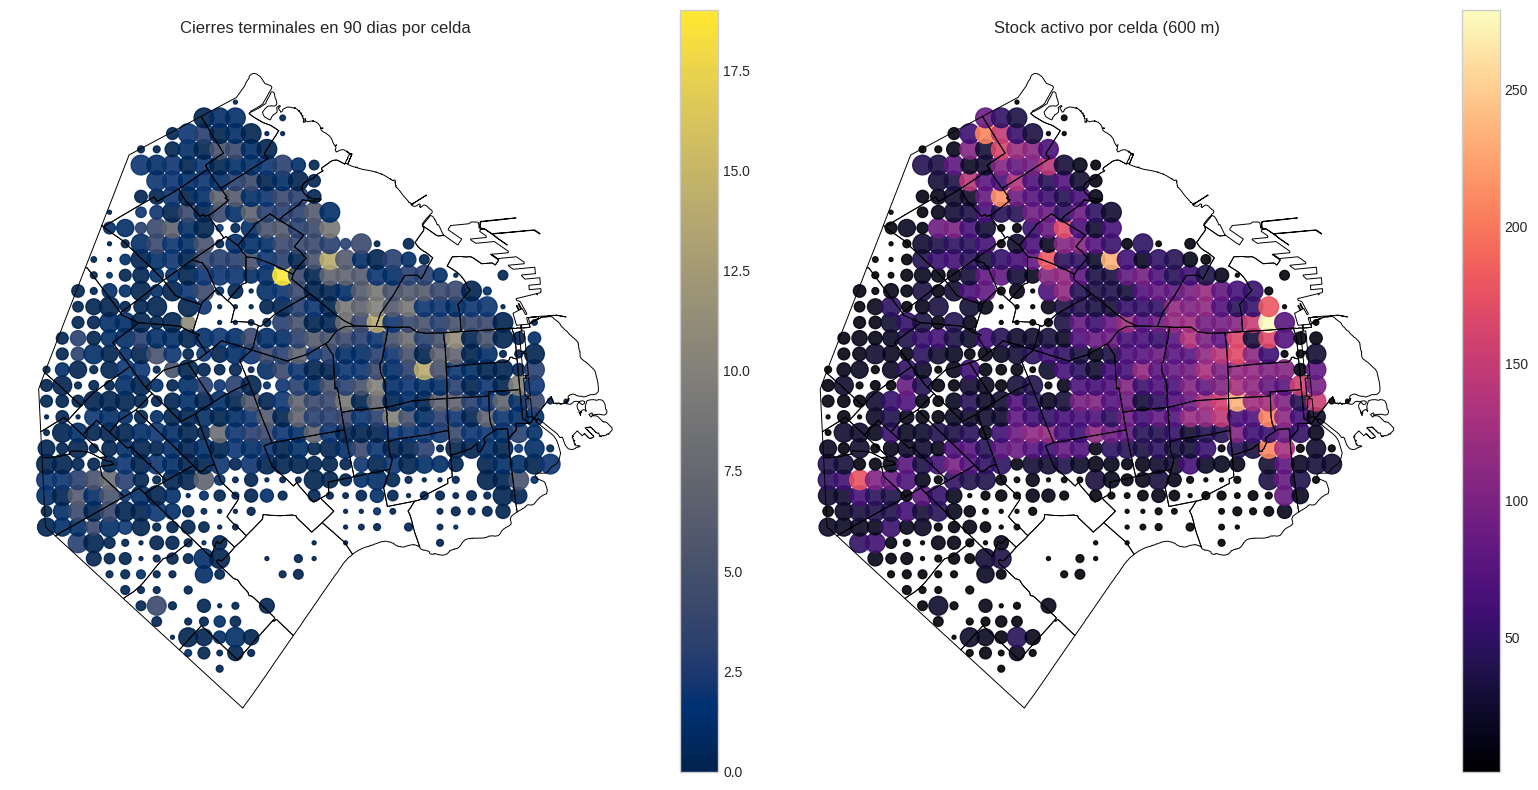

In [19]:
plot_closed_count_df = plot_two_panel_grid_summary(
    turnover_grid_gdf,
    barrios_turnover_m,
    value_col="cierres_90d",
    value_title=f"Cierres terminales en {CLOSURE_WINDOW_DAYS} dias por celda",
    value_cmap="cividis",
    min_obs=MIN_TURNOVER_STOCK_PER_CELL,
    support_col="stock_activo",
    support_title=f"Stock activo por celda ({GRID_STEP_METERS} m)",
)

plot_closed_count_df[["cierres_90d", "stock_activo", "tasa_cierre_sobre_stock_90d"]].sort_values(
    ["cierres_90d", "stock_activo"],
    ascending=[False, False],
).head(15)


El conteo bruto de cierres está influido por la densidad de publicaciones. Por eso conviene leer este mapa junto al de tasa de cierres sobre stock: una zona puede registrar muchos cierres en términos absolutos y, aun así, no mostrar una rotación especialmente alta si el stock activo también es grande.


## Departamentos vendidos por ambientes

En esta sección tomamos cierres terminales históricos, filtramos a departamentos solo para este análisis y resumimos cuántos se vendieron por `ambientes` y cuáles son sus metros cuadrados típicos.


In [20]:
SOLD_DEPARTAMENTO_REGEX = r"depto|departamento"

df_sold = load_history_df(PROCESSED_DATA_PATH).copy()
processed_id_col = resolve_processed_id_column(df_sold.columns)
df_sold = df_sold.rename(columns={processed_id_col: "publication_id"})

active_ids_sold = set(df_sold.loc[df_sold["valido_hasta"].isna(), "publication_id"].dropna())

sold_terminal_df = df_sold.loc[df_sold["valido_hasta"].notna()].copy()
sold_terminal_df = sold_terminal_df.sort_values(["publication_id", "valido_hasta", "valido_desde"])
sold_terminal_df = sold_terminal_df.groupby("publication_id", as_index=False).tail(1)
if active_ids_sold:
    sold_terminal_df = sold_terminal_df.loc[~sold_terminal_df["publication_id"].isin(active_ids_sold)].copy()

sold_terminal_df = filter_departamentos(sold_terminal_df, SOLD_DEPARTAMENTO_REGEX)
sold_terminal_df["ambientes"] = pd.to_numeric(sold_terminal_df["ambientes"], errors="coerce")
sold_terminal_df["area_m2_total"] = pd.to_numeric(sold_terminal_df["area_m2_total"], errors="coerce")
sold_terminal_df = sold_terminal_df.loc[sold_terminal_df["ambientes"].notna()].copy()
sold_terminal_df = sold_terminal_df.loc[sold_terminal_df["ambientes"] > 0].copy()
sold_terminal_df["ambientes"] = sold_terminal_df["ambientes"].round().astype(int)

sold_by_ambientes = (
    sold_terminal_df
    .groupby("ambientes", as_index=False)
    .agg(
        dptos_vendidos=("publication_id", "nunique"),
        area_m2_promedio=("area_m2_total", "mean"),
        area_m2_mediana=("area_m2_total", "median"),
    )
    .sort_values("ambientes")
)

display(
    pd.Series(
        {
            "cierres_terminales_totales": int(df_sold.loc[df_sold["valido_hasta"].notna(), "publication_id"].nunique()),
            "departamentos_vendidos": int(sold_terminal_df["publication_id"].nunique()),
            "ambientes_distintos": int(sold_by_ambientes["ambientes"].nunique()),
            "area_m2_promedio_global": round(sold_terminal_df["area_m2_total"].mean(), 2),
        }
    ).to_frame("valor")
)

sold_by_ambientes


,valor
cierres_terminales_totales,21735.00
departamentos_vendidos,43.00
ambientes_distintos,5.00
area_m2_promedio_global,51.19


,ambientes,dptos_vendidos,area_m2_promedio,area_m2_mediana
0,1,13,25.590769,27.00
1,2,15,39.520667,40.00
2,3,8,64.392500,64.57
3,4,6,111.000000,92.00
4,5,1,94.570000,94.57


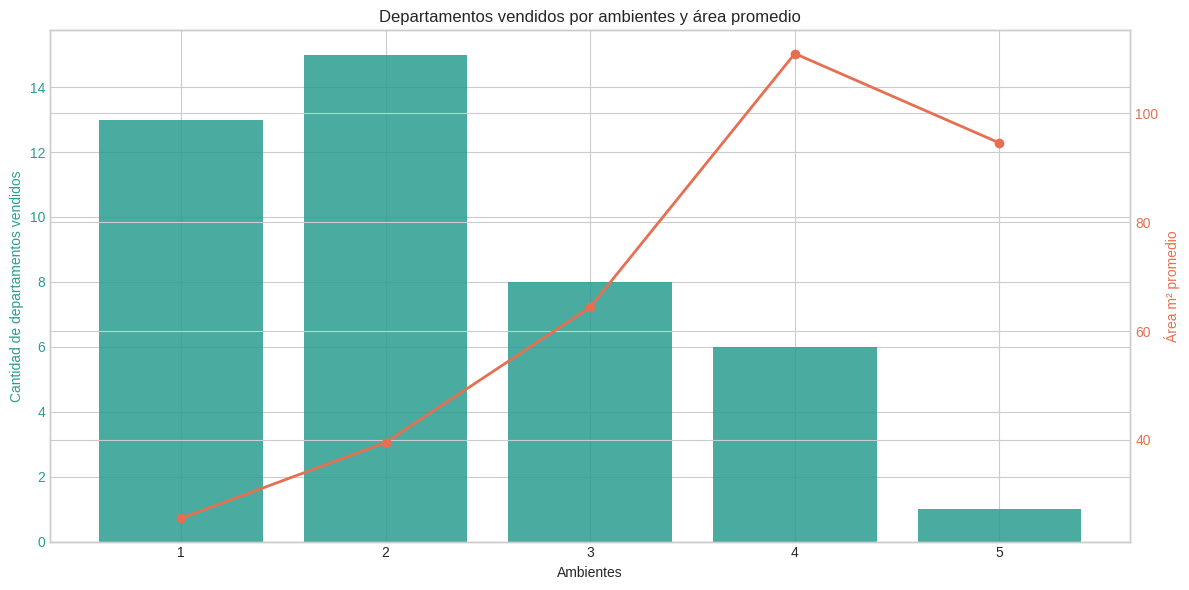

In [21]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    sold_by_ambientes["ambientes"].astype(str),
    sold_by_ambientes["dptos_vendidos"],
    color="#2a9d8f",
    alpha=0.85,
)
ax1.set_xlabel("Ambientes")
ax1.set_ylabel("Cantidad de departamentos vendidos", color="#2a9d8f")
ax1.tick_params(axis="y", labelcolor="#2a9d8f")

ax2 = ax1.twinx()
ax2.plot(
    sold_by_ambientes["ambientes"].astype(str),
    sold_by_ambientes["area_m2_promedio"],
    color="#e76f51",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Área m² promedio", color="#e76f51")
ax2.tick_params(axis="y", labelcolor="#e76f51")

plt.title("Departamentos vendidos por ambientes y área promedio")
plt.tight_layout()


En términos agregados, la mayor parte de los cierres parece concentrarse en monoambientes cercanos a 25 m² y en unidades de 2 ambientes alrededor de 40 m². Esto sugiere que el mercado se mueve con más intensidad en tipologías relativamente compactas, algo relevante si después querés cruzar liquidez con oportunidades de precio.


Estas conclusiones también aparecen en el gráfico siguiente. A la izquierda se muestra la distribución de los metros cuadrados de las propiedades vendidas y, a la derecha, un boxplot de `area_m2_total` por cantidad de ambientes.

Se observan concentraciones relativamente claras alrededor de 25 m², 40 m² y 65 m², consistentes con tipologías compactas de 1, 2 y 3 ambientes, respectivamente. Esa estructura sugiere que parte importante de los cierres se agrupa en segmentos bastante reconocibles del mercado.


/tmp/ipykernel_887704/283601781.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(boxplot_data, labels=[str(x) for x in ordered_ambientes], patch_artist=True)


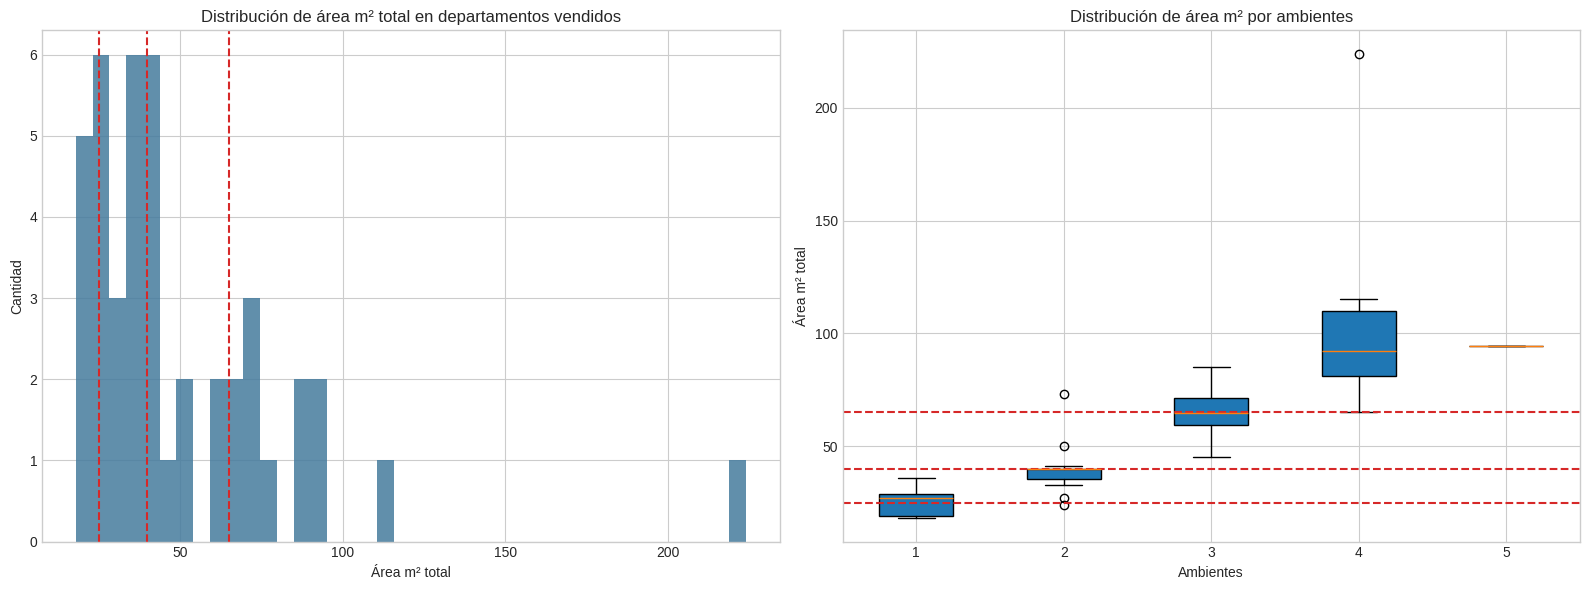

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

reference_areas = [25, 40, 65]
reference_color = "#d62828"

sold_terminal_df["area_m2_total"].dropna().plot(
    kind="hist",
    bins=40,
    ax=axes[0],
    color="#457b9d",
    alpha=0.85,
)
for area in reference_areas:
    axes[0].axvline(area, color=reference_color, linestyle="--", linewidth=1.5)
axes[0].set_title("Distribución de área m² total en departamentos vendidos")
axes[0].set_xlabel("Área m² total")
axes[0].set_ylabel("Cantidad")

boxplot_df = sold_terminal_df.loc[
    sold_terminal_df["area_m2_total"].notna(),
    ["ambientes", "area_m2_total"],
].copy()
ordered_ambientes = sorted(boxplot_df["ambientes"].unique())
boxplot_data = [
    boxplot_df.loc[boxplot_df["ambientes"] == ambientes, "area_m2_total"].values
    for ambientes in ordered_ambientes
]

axes[1].boxplot(boxplot_data, labels=[str(x) for x in ordered_ambientes], patch_artist=True)
for area in reference_areas:
    axes[1].axhline(area, color=reference_color, linestyle="--", linewidth=1.5)
axes[1].set_title("Distribución de área m² por ambientes")
axes[1].set_xlabel("Ambientes")
axes[1].set_ylabel("Área m² total")

plt.tight_layout()
